In [1]:
#import python classes and packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer #loading tfidf vector
from sklearn.metrics import accuracy_score
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D
from keras.models import Sequential, load_model, Model
import pickle
import os
from keras.callbacks import ModelCheckpoint
from nltk.corpus import stopwords
import nltk
from string import punctuation
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [2]:
#define object to remove stop words and other text processing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
ps = PorterStemmer()

In [3]:
#define function to clean text by removing stop words and other special symbols
def cleanText(doc):
    tokens = doc.split()
    table = str.maketrans('', '', punctuation) #remove punctuation
    tokens = [w.translate(table) for w in tokens]
    tokens = [word for word in tokens if word.isalpha()]#take only alphabets
    tokens = [w for w in tokens if not w in stop_words]#remove stop words
    tokens = [word for word in tokens if len(word) > 1]
    tokens = [ps.stem(token) for token in tokens] #apply stemming and lemmatization
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    tokens = ' '.join(tokens)
    return tokens

In [4]:
#loading and displaying disease outbreak dataset obtained from social media and other health centers
dataset = pd.read_csv("Dataset/Outbreak.csv")
dataset

,Date,Link,Description,Country,Outbreak,Temperature,Humidity
0,4 january 2019,https://reliefweb.int/report/democratic-republ...,The response by WHO and partners to the ongoin...,Democratic Republic of the Congo,Ebola virus disease,27.68,62.0
1,4 january 2019,https://www.who.int/emergencies/disease-outbre...,The Panama Ministry of Health has reported an ...,Republic of Panama,Hantavirus disease,23.17,98.0
2,8 january 2019,https://www.who.int/emergencies/disease-outbre...,"As of October 2018, genetically-linked circula...",Democratic Republic of the Congo,Poliomyelitis,27.68,62.0
3,9 january 2019,https://reliefweb.int/report/nigeria/disease-o...,"On 22 November 2018, the World Health Organiza...",Nigeria,Yellow fever,18.27,24.0
4,10 january 2019,https://reliefweb.int/report/democratic-republ...,WHO and partners continue to respond to the on...,Democratic Republic of the Congo,Ebola virus disease,27.68,62.0
...,...,...,...,...,...,...,...
114,17 december 2019,https://reliefweb.int/report/nigeria/disease-o...,Nigeria is responding to successive yellow fev...,Nigeria,Yellow fever,18.27,24.0
115,18 december 2019,https://www.who.int/csr/don/18-december-2019-m...,NaN,CoV),Middle East respiratory syndrome coronavirus (...,NaN,NaN
116,19 december 2019,https://reliefweb.int/report/democratic-republ...,Disease outbreak news: Update\n19 December 201...,Democratic Republic of the Congo,Ebola virus disease,27.68,62.0
117,26 december 2019,https://www.who.int/csr/don/26-december-2019-m...,NaN,CoV),Middle East respiratory syndrome coronavirus (...,NaN,NaN


In [5]:
#finding and displaying count of missing or null values
dataset.isnull().sum()

Date            0
Link            0
Description    17
Country         0
Outbreak        0
Temperature    37
Humidity       37
dtype: int64

In [6]:
#replacing misisng values with mean
dataset['Temperature'] = dataset['Temperature'].fillna(value=dataset['Temperature'].mean())
dataset['Humidity'] = dataset['Humidity'].fillna(value=dataset['Humidity'].mean())
dataset['Description'] = dataset['Description'].fillna(value="")
#finding and displaying count of missing or null values
dataset.isnull().sum()

Date           0
Link           0
Description    0
Country        0
Outbreak       0
Temperature    0
Humidity       0
dtype: int64

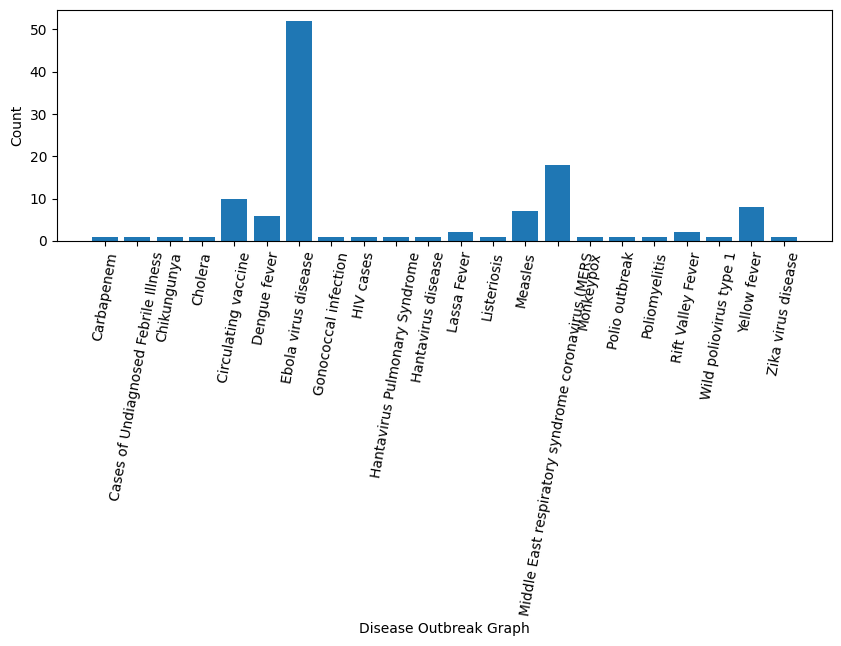

In [7]:
#finding & plotting graph of different outbreaks exists in dataset
labels, count = np.unique(dataset['Outbreak'].ravel(), return_counts = True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (10, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Disease Outbreak Graph")
plt.ylabel("Count")
plt.xticks(rotation=80)
plt.show()

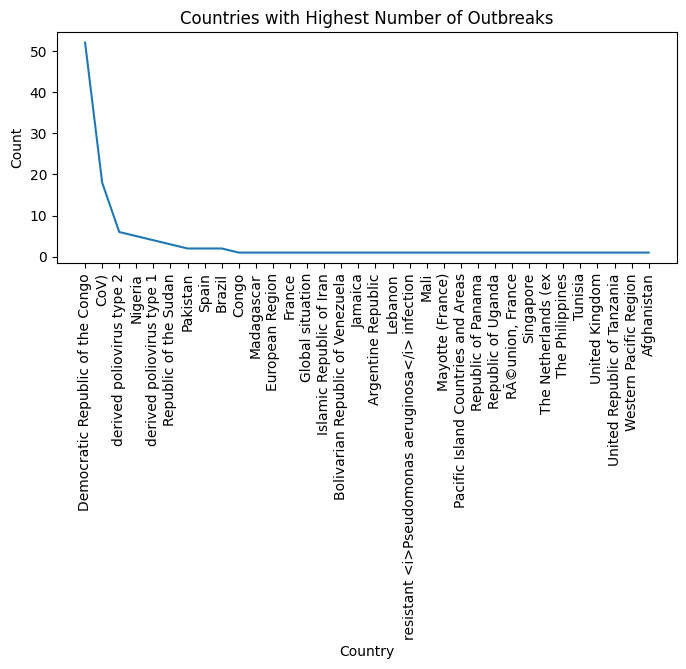

In [8]:
#crimes in each community
data = dataset.groupby(["Country"])['Outbreak' ].count().sort_values(ascending=False).reset_index(name='Count')
plt.figure(figsize=(8, 3))
sns.lineplot(data=data, x="Country", y="Count")
plt.xticks(rotation=90)
plt.title("Countries with Highest Number of Outbreaks")
plt.show()

In [9]:
#return integer label for given disease name
def getLabel(name):
    index = -1
    count = 0
    for i in range(len(labels)):
        if labels[i] == name:
            index = i
            count = counter[i]
            break
    return index, count

In [10]:
#dataset processing such as extracting environment and news data
if os.path.exists("model/X.npy"):#if data already process then load
    X = np.load("model/X.npy")
    Y = np.load("model/Y.npy")
    environment = np.load("model/environment.npy")
    temperature, humidity = environment
else:
    #read each social media and environment data and then clean and extract features
    desc = dataset['Description']
    outbreak = dataset['Outbreak']
    X = []
    Y = []
    for i in range(len(desc)):#loop and read each news description
        news = str(desc[i])
        news = news.strip('\n').strip().lower()#remove spaces and convert to lower case
        if len(news) > 0:
            news = cleanText(news)#clean news by removing stop words and other symbols
            label, count = getLabel(outbreak[i])#get disease label for given news
            X.append(news)#ad to x and y training array
            Y.append(label)
print("Dataset Loading Completed")
print("Different Social Media Disease Articles = "+str(X.shape[0]))

Dataset Loading Completed
Different Social Media Disease Articles = 371


In [11]:
#dataset processing such as shuffling, numeric vector conversion from news text and then normalizing 
#training features
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle features
X = X[indices]
Y = Y[indices]
#generate numeric vector from social media news text
tfidf_vectorizer = TfidfVectorizer(use_idf=True, smooth_idf=False, norm=None, decode_error='replace', max_features=2350)
X = tfidf_vectorizer.fit_transform(X).toarray()
X = np.column_stack((X, temperature))
X = np.column_stack((X, humidity))
#normalize training features
scaler = MinMaxScaler((0, 1))
X = scaler.fit_transform(X)
print("Normalized Features = "+str(X))

Normalized Features = [[0.         0.         0.         ... 0.         0.91121076 0.55294118]
 [0.         0.         0.         ... 0.         0.81008969 0.97647059]
 [0.         0.         1.         ... 0.         0.81008969 0.97647059]
 ...
 [0.         0.         0.         ... 0.         0.91121076 0.55294118]
 [0.         0.         0.         ... 0.         0.80610576 0.50832138]
 [0.         0.         0.         ... 0.         0.64058296 0.12941176]]


In [12]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Train & Test Dataset Split")
print("80% records used to train algorithms : "+str(X_train.shape[0]))
print("20% records features used to test algorithms : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Train & Test Dataset Split
80% records used to train algorithms : 296
20% records features used to test algorithms : 75


In [13]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [14]:
#define function to calculate accuracy and other metrics
def calculateMetrics(algorithm, predict, y_test):
    a = accuracy_score(y_test,predict)*100
    p = precision_score(y_test, predict,average='macro') * 100
    r = recall_score(y_test, predict,average='macro') * 100
    f = f1_score(y_test, predict,average='macro') * 100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  :  "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FScore    : "+str(f))    

In [15]:
#training random forest on 80% training features and then performing prediction on 20% test data to calculate accuracy and 
#other metrics
#defining tuning parameters
param_grid = {'n_estimators': [100], 'max_depth': [2, 3]}
tune_rf = GridSearchCV(RandomForestClassifier(), param_grid)
#training on train data
tune_rf.fit(X_train, y_train)
#performing prediction on test data
predict = tune_rf.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Random Forest", predict, y_test)

Random Forest Accuracy  :  81.33333333333333
Random Forest Precision : 69.61895869458894
Random Forest Recall    : 72.38095238095238
Random Forest FScore    : 67.92976449839195


In [16]:
#training decision tree on 80% training features and then performing prediction on 20% test data to calculate accuracy and 
#other metrics
#defining tuning parameters
param_grid = {'min_samples_split': [0.2, 0.5, 0.7], 'criterion': ["gini"]}
tune_dt = GridSearchCV(DecisionTreeClassifier(), param_grid)
#training on train data
tune_dt.fit(X_train, y_train)
#performing prediction on test data
predict = tune_dt.predict(X_test)
#call this function to calculate accuracy and other metrics
calculateMetrics("Decision Tree", predict, y_test)

Decision Tree Accuracy  :  85.33333333333334
Decision Tree Precision : 78.25396825396825
Decision Tree Recall    : 82.3809523809524
Decision Tree FScore    : 77.62197702047328


In [17]:
#training CNN newural network algorithm on training features
X_train1 = np.reshape(X_train, (X_train.shape[0], 28, 28, 3))
X_test1 = np.reshape(X_test, (X_test.shape[0], 28, 28, 3))
y_train1 = to_categorical(y_train)
y_test1 = to_categorical(y_test)
#defining neural network object
cnn_model = Sequential()
#adding CNN layer with 32 neurons of 3 X 3 matrix to filter features
cnn_model.add(Convolution2D(32, (3 , 3), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
#max layer to collect relevant features from CNN layer
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
#defining another layer to further optimzie features
cnn_model.add(Convolution2D(32, (3, 3), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = y_train1.shape[1], activation = 'softmax'))
#compiling training and loading model
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X_train1, y_train1, batch_size = 32, epochs = 100, validation_data=(X_test1, y_test1), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn_model.load_weights("model/cnn_weights.hdf5")
#performing prediction on test data
predict = cnn_model.predict(X_test1)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test1, axis=1)
#call this function to calculate accuracy and other metrics
calculateMetrics("Neural Network", predict, y_test1)



Neural Network Accuracy  :  92.0
Neural Network Precision : 91.4038342609771
Neural Network Recall    : 88.4126984126984
Neural Network FScore    : 87.78533635676494


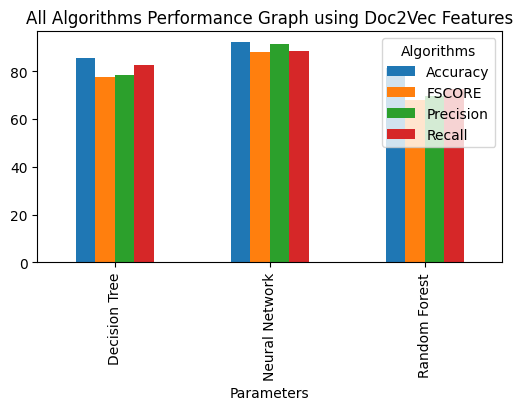

In [18]:
#plot all algorithm performance in tabukar format
df = pd.DataFrame([['Random Forest','Accuracy',accuracy[0]],['Random Forest','Precision',precision[0]],['Random Forest','Recall',recall[0]],['Random Forest','FSCORE',fscore[0]],
                   ['Decision Tree','Accuracy',accuracy[1]],['Decision Tree','Precision',precision[1]],['Decision Tree','Recall',recall[1]],['Decision Tree','FSCORE',fscore[1]],
                   ['Neural Network','Accuracy',accuracy[2]],['Neural Network','Precision',precision[2]],['Neural Network','Recall',recall[2]],['Neural Network','FSCORE',fscore[2]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph using Doc2Vec Features")
plt.show()

In [19]:
#display all algorithm performnace
algorithms = ['Random Forest', 'Decision Tree', 'Neural Network']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Random Forest,81.333333,69.618959,72.380952,67.929764
1,Decision Tree,85.333333,78.253968,82.380952,77.621977
2,Neural Network,92.000000,91.403834,88.412698,87.785336
